# Build a Basic Chatbot with LangGraph (Graph API)

In [5]:
from typing import Annotated 

from typing_extensions import TypedDict 

from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages 

In [6]:
class State(TypedDict): 
    # Messages have the type "list". The 'add_messages' function 
    # in the annotation defines how this state key should be updated 
    # (in this case, it appends messages to the list, rather than overwritting them)
    messages: Annotated[list,add_messages]


In [7]:
import os 
from dotenv import load_dotenv 
load_dotenv()


True

In [8]:
from langchain_groq import ChatGroq 
from langchain.chat_models import init_chat_model

model = init_chat_model("groq:qwen/qwen3.6-27b")

In [9]:
## Node funcitonality   
def chatbot(state: State): 
    return {"messages": [model.invoke(state['messages'])]}

In [10]:
graph_builder = StateGraph(State)

## Adding node 
graph_builder.add_node("llmchatbot", chatbot) # here we are creating a node and adding it's functionality in the node from the node funciton 

## Adding edges 
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph 
graph = graph_builder.compile()

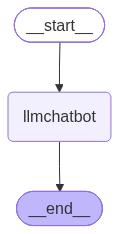

In [11]:
## Visualize the graph 
from IPython.display import Image, display 

try: 
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("there was an error laoding the image")  

In [12]:
response = graph.invoke({"messages": "Hi"})

In [13]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='21e8de3d-959f-4502-b8ff-7807cffac57a'),
 AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user simply said "Hi". This is a standard greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or task is provided.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Offer assistance\n   - Keep it open-ended to encourage the user to share what they need\n   - Maintain a friendly, helpful tone\n4.  **Draft Response (Mental):** "Hi there! How can I help you today?" \n5.  **Refine Response:** Keep it concise and inviting. Maybe add a touch of warmth: "Hello! How can I assist you today?" or "Hi! What\'s on your mind? I\'m here to help with anything you need."\n6.  **Final Output Generation:** Match the refined version. Ensure it\'s natural and aligns with standard AI assistant behavior.✅\n</think>\n\nHello! H

In [14]:
for event in graph.stream({"messages": "Hi, How are you ?"}): 
    for value in event.values(): 
        print(value)

{'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi, How are you ?"\n   - This is a standard greeting and a polite inquiry about my well-being.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hi"\n   - Question: "How are you?"\n   - Tone: Casual, friendly\n\n3.  **Determine Response Goals:**\n   - Acknowledge the greeting\n   - Respond to the question appropriately (as an AI, I don\'t have feelings, but I can acknowledge that politely)\n   - Keep it friendly and conversational\n   - Offer assistance\n\n4.  **Draft Response (Mental):**\n   Hi! I\'m doing well, thank you for asking. I\'m here and ready to help you with whatever you need. How are you doing today?\n\n5.  **Refine Response (Self-Correction/Verification):**\n   - Does it match the tone? Yes, friendly and polite.\n   - Does it address the question? Yes, acknowledges it while staying true to AI nature.\n   - Does it invite further conversation? Yes, ask

## Chatbot with Tools 

In [15]:
from langchain_tavily import TavilySearch 

tool = TavilySearch(max_result=2)
tool.invoke("What is langgraph and langchain?")

{'query': 'What is langgraph and langchain?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.truefoundry.com/blog/langchain-vs-langgraph',
   'title': 'LangChain vs LangGraph: Compare Features & Use Cases',
   'content': 'Both LangChain and LangGraph are powerful tools for building LLM-powered applications, each excelling in different scenarios. LangChain is ideal for simpler, linear workflows that benefit from rapid prototyping and extensive integrations, while LangGraph is designed for complex, adaptive, and stateful agent systems. Choosing the right one depends on your project’s complexity and long-term goals. Regardless of your choice, pairing these frameworks with TrueFoundry as your AI Gateway ensures your [...] LangGraph is an open-source framework from the LangChain team that helps developers build smarter and more adaptable AI agent workflows. Instead of running tasks in a straight line like a traditional chain, LangGraph organi

In [16]:
## custom function 
def multiply(a: int, b:int)-> int: 
    """Multiply a and b 
    
    Args: 
        a (int): first int 
        b (int): second int 
    
    Returns: 
        int: output int 
    
    """
    return a* b

In [17]:
tools = [tool, multiply]

In [18]:
llm_with_tool = model.bind_tools(tools)
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.5', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x000002C3173A6CF0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002C3173A7770>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'str

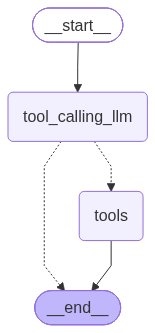

In [19]:
## Stategraph 
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition 

## Node defination 
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state["messages"])]}

## graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))


## Add Edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools 
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END 
    tools_condition
)
builder.add_edge("tools", END)

## compile the graph 
graph = builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))


In [20]:
response = graph.invoke({"messages": "What is the recent ai news? "})

In [21]:
response['messages'][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/products/ads-commerce/google-ads-analytics-ai-updates", "title": "Evolve your marketing with new AI tools", "content": "Currently available in beta for English language accounts\\n\\n## Related stories\\n\\n### The latest AI news we announced in July 2026\\n\\n### Inside our 353,000-person vibe coding course\\n\\n### Prepare for the holiday season with July’s Demand Gen Drop.\\n\\n### Gemini API Managed Agents: 3.6 Flash, hooks, and more\\n\\n### 5 ways to host the ultimate dinner party with Google Search\\n\\n### 5 ways AI Mode in Search helps you enjoy the real world", "score": 0.8029425, "published_date": "Mon, 10 Aug 2026 14:31:52 GMT", "raw_content": null, "id": "ab4ae2-00"}, {"url": "https://www.businessinsider.com/ai-cybersecurity-incidents-openai-astra-anthropic-kimi-meta-2026-8", "title": "The world\'s leading AI companies are all struggling to conta

In [22]:
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news? 
================================== Ai Message ==================================
Tool Calls:
  tavily_search (t3h7epbq7)
 Call ID: t3h7epbq7
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/products/ads-commerce/google-ads-analytics-ai-updates", "title": "Evolve your marketing with new AI tools", "content": "Currently available in beta for English language accounts\n\n## Related stories\n\n### The latest AI news we announced in July 2026\n\n### Inside our 353,000-person vibe coding course\n\n### Prepare for the holiday season with July’s Demand Gen Drop.\n\n### Gemini API Managed Agents: 3.6 Flash, hook

In [23]:
response = graph.invoke({"messages": "what is 2 multiplied by 3"})
for m in response["messages"]: 
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplied by 3
================================== Ai Message ==================================
Tool Calls:
  multiply (07mfndrq2)
 Call ID: 07mfndrq2
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [24]:
response = graph.invoke({"messages": "Give the recent ai news and then multiply 5 by 10"})
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

Give the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (mjt5cm93j)
 Call ID: mjt5cm93j
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "Altudo released Fastlane, a migration tool designed to transition legacy websites to Sitecore. Generative AI models automate content mapping and translate old codebases into the new platform structure.\n\nAscendios AI deployed an autonomous video ad generator. The system pr

## ReAct Agent Architecture 

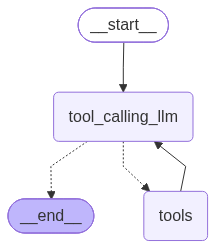

In [25]:
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition 


## Node Definition 
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state["messages"])]}


## graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Add Edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    tools_condition 
)
builder.add_edge("tools", "tool_calling_llm")


## compile graph 
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
response = graph.invoke({"messages": "Give me the recent ai news and then multipy 5 by 10"})
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multipy 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (f4mqbdphy)
 Call ID: f4mqbdphy
  Args:
    query: recent ai news
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/products/ads-commerce/google-ads-analytics-ai-updates", "title": "Evolve your marketing with new AI tools", "content": "Currently available in beta for English language accounts\n\n## Related stories\n\n### The latest AI news we announced in July 2026\n\n### Inside our 353,000-person vibe coding course\n\n### Prepare for the holiday season with July’s Demand Gen Drop.\n\n### Gemini API Managed 

## Adding Memory In Agentic Graph 

In [27]:
response = graph.invoke({"messages": "What is my name?"})
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

I don't have access to your personal information, so I don't know your name. If you'd like to share it, I'd be happy to use it in our conversation! Otherwise, feel free to just chat as you are. How can I help you today?


In [28]:
response = graph.invoke({"messages": "what is my name?"})
for m in response['messages']: 
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I don't actually know your name! As an AI, I don't have access to your personal information or account details. If you'd like, you can tell me your name and I'll gladly use it in our conversation.


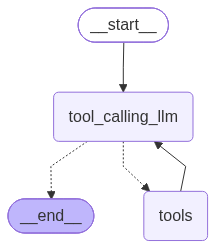

In [29]:
from langgraph.graph import StateGraph, START, END 
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition 
from langgraph.checkpoint.memory import MemorySaver 

# intilize memory 
memory = MemorySaver()

# node definition 
def tool_calling_llm(state: State): 
    return {"messages": [llm_with_tool.invoke(state['messages'])]}

## graph 
builder = StateGraph(State)

## nodes 
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

## Edges 
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm", tools_condition)
builder.add_edge('tools', 'tool_calling_llm')

## compile graph 
graph = builder.compile(checkpointer = memory) 

display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
config = {"configurable": {"thread_id": "1"}}

response = graph.invoke({"messages": "Hi, my name is manash"}, config = config)

response 

{'messages': [HumanMessage(content='Hi, my name is manash', additional_kwargs={}, response_metadata={}, id='5e97ea06-95bf-4934-a632-d0c7c429d6df'),
  AIMessage(content="Hello Manash! It's nice to meet you. How can I help you today?", additional_kwargs={'reasoning_content': 'The user is introducing themselves as "manash".\nI should greet them by name.\nNo tools are needed for this simple greeting.\nI will respond politely.\n\nPlan:\n1. Acknowledge the user\'s name.\n2. Offer assistance.\n'}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 1910, 'total_tokens': 1985, 'completion_time': 0.142470035, 'completion_tokens_details': {'reasoning_tokens': 54}, 'prompt_time': 0.135849424, 'prompt_tokens_details': None, 'queue_time': 0.045103808, 'total_time': 0.278319459}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_2f860a3fc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00552-bbb2-

In [31]:
response = graph.invoke({"messages": "What is my name?"}, config = config)
print(response['messages'][-1].content)

Your name is Manash.


### Streaming in LangGraph


In [32]:
from langgraph.checkpoint.memory import MemorySaver 
memory = MemorySaver()

In [33]:
def superbot(state: State): 
    return {"messages": [model.invoke(state['messages'])]}

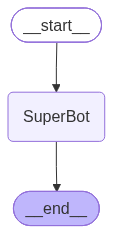

In [34]:
graph = StateGraph(State) 

## node 
graph.add_node("SuperBot", superbot)

## Edges 
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END) 

graph_builder=graph.compile(checkpointer = memory)


## Display 
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [35]:
## Invocation 

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({"messages": "Hi, my name is manash and i like cricke"}, config = config)

{'messages': [HumanMessage(content='Hi, my name is manash and i like cricke', additional_kwargs={}, response_metadata={}, id='f2c86fa8-9499-4725-97f9-2218b9a21008'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Manash\n   - Interest: Cricket\n   - Greeting: "Hi, my name is manash and i like cricke" (note: "cricke" is likely a typo for "cricket")\n\n2.  **Identify Key Elements:**\n   - Personal greeting with name\n   - Shared interest (cricket)\n   - Minor typo ("cricke" → "cricket")\n\n3.  **Determine Response Goals:**\n   - Acknowledge and greet by name\n   - Acknowledge and validate the interest in cricket\n   - Keep it friendly and engaging\n   - Ask a follow-up question to encourage conversation\n   - Correct the typo implicitly (use "cricket" naturally)\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Manash! Nice to meet you. Cricket is such an amazing sport—whether you\'re into watching matches, playing, or following

#### Streaming 

Methods: stream() and astream()

    - These methods are sync and async methods for streaming back results 

Additional parameters in streaming nodes for graph state 

    - values: This streams the full state of the grpeah after each node is called 
    - updates: This streams updates to the state of the graph after each node is called 

In [36]:
# Create a thread 
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is manash and I like cricket"}, config, stream_mode="updates"): 
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Manash\n   - Interest: Cricket\n   - Greeting: "Hi, My name is manash and I like cricket"\n\n2.  **Identify Key Elements:**\n   - Personal greeting/name recognition\n   - Shared interest/topic (cricket)\n   - Open-ended, conversational tone\n\n3.  **Determine Response Goals:**\n   - Acknowledge the name politely\n   - Acknowledge the interest in cricket\n   - Engage conversationally (ask a question, offer to discuss cricket topics)\n   - Keep it friendly and open-ended\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Manash! Nice to meet you. Cricket\'s an amazing sport—there\'s so much to talk about, whether it\'s your favorite team, players, format (Test, ODI, T20), or even recent matches. What aspect of cricket do you enjoy the most? Or are you following any particular tournament right now?\n\n5.  **Check Against Guidelines:**\n   - Personalized? Yes, 

In [37]:
for chunk in graph_builder.stream({"messages": "Hi, My name is manash and I like cricket"}, config, stream_mode="values"): 
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is manash and I like cricket', additional_kwargs={}, response_metadata={}, id='e2cc602b-fe7a-4dfb-9446-fc94f3827b38'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Manash\n   - Interest: Cricket\n   - Greeting: "Hi, My name is manash and I like cricket"\n\n2.  **Identify Key Elements:**\n   - Personal greeting/name recognition\n   - Shared interest/topic (cricket)\n   - Open-ended, conversational tone\n\n3.  **Determine Response Goals:**\n   - Acknowledge the name politely\n   - Acknowledge the interest in cricket\n   - Engage conversationally (ask a question, offer to discuss cricket topics)\n   - Keep it friendly and open-ended\n\n4.  **Draft Response (Mental Refinement):**\n   Hi Manash! Nice to meet you. Cricket\'s an amazing sport—there\'s so much to talk about, whether it\'s your favorite team, players, format (Test, ODI, T20), or even recent matches. What aspect of cricket do 

In [38]:
# Create a thread 
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": "Hi, My name is manash and I like cricket"}, config, stream_mode="values"): 
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is manash and I like cricket', additional_kwargs={}, response_metadata={}, id='46606989-f773-4481-bca7-64311b2f250b')]}
{'messages': [HumanMessage(content='Hi, My name is manash and I like cricket', additional_kwargs={}, response_metadata={}, id='46606989-f773-4481-bca7-64311b2f250b'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Manash\n   - Interest: Cricket\n   - Greeting: "Hi"\n\n2.  **Identify Key Elements:**\n   - Personal greeting/name acknowledgment\n   - Shared interest/topic (cricket)\n   - Opportunity for engagement/conversation\n\n3.  **Determine Response Goals:**\n   - Acknowledge the name politely\n   - Acknowledge and engage with the cricket interest\n   - Ask open-ended questions to continue the conversation\n   - Keep it friendly and conversational\n\n4.  **Draft - Mental Refinement:**\n   Hi Manash! Nice to meet you. Cricket is such a fantastic sport—there\'s so muc

In [39]:
for chunk in graph_builder.stream({"messages": "I also like football"}, config, stream_mode="values"): 
    print(chunk)

{'messages': [HumanMessage(content='Hi, My name is manash and I like cricket', additional_kwargs={}, response_metadata={}, id='46606989-f773-4481-bca7-64311b2f250b'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Manash\n   - Interest: Cricket\n   - Greeting: "Hi"\n\n2.  **Identify Key Elements:**\n   - Personal greeting/name acknowledgment\n   - Shared interest/topic (cricket)\n   - Opportunity for engagement/conversation\n\n3.  **Determine Response Goals:**\n   - Acknowledge the name politely\n   - Acknowledge and engage with the cricket interest\n   - Ask open-ended questions to continue the conversation\n   - Keep it friendly and conversational\n\n4.  **Draft - Mental Refinement:**\n   Hi Manash! Nice to meet you. Cricket is such a fantastic sport—there\'s so much to love about it. Are you a fan of a particular team or player, or do you follow international matches, IPL, or maybe even play it yourself? I\'d love to hear what as

In [40]:
# Create a thread 
config = {"configurable": {"thread_id": "5"}}

## Astream is mostly used in debugging 
async for event in graph_builder.astream_events({"messages": "Hi, My name is manash and I like cricket"}, config, version ="v2"): 
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, My name is manash and I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a00553-778f-7452-b777-2d60dc7cc4cd', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My name is manash and I like cricket', additional_kwargs={}, response_metadata={}, id='63bc07f2-77b6-4aad-9fcd-5f9a21f62e95')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a00553-7791-7772-8293-ba849b12749e', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:051d5dc2-0c63-098d-619c-b8d99286420e'}, 'parent_ids': ['01a00553-778f-7452-b777-2d60dc7cc4cd']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag